<a href="https://colab.research.google.com/github/LampOfSocrates/reid/blob/main/EEEM071_CourseWork2604_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# This insures that 2 seconda after editing a module it gets reloaded without restarting the kernel
%load_ext autoreload
%autoreload 2

# Step 1: GPU Selection
1. Find "Edit" tab above, select "Hardware accelerator" and choose "GPU"
2. Run bellow command to check what GPU you got

In [2]:
from datetime import datetime

NOTEBOOK_START_TIME = datetime.now()

In [3]:
!nvidia-smi

Sun Apr 26 20:33:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.97                 Driver Version: 595.97         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5070 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
| 30%   43C    P8             25W /  300W |    8963MiB /  16303MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Step 2: Code Preparation

We need to maintain our codebase with git history, so a file system (Google Drive) is needed
1. Select the left file icon and mount your Google Drive
2. Move path to Google Drive
3. Git clone code base


In [4]:
%%time

from pathlib import Path
import sys
import os

def is_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

if is_colab():
  from google.colab import drive
  drive.mount('/content/drive')

  %cd /content
  #!pip install -U --no-cache-dir gdown --pre

  # please download datasets from assignment doc link and upload, then unzip it.

  # Copy the uploaded zip from Google Drive into the Colab runtime, then unzip it locally.
  if not os.path.exists('/content/VeRi'):
      print('Unzipping VeRi dataset...')
      !cp "/content/drive/MyDrive/Colab Notebooks/data/VeRi.zip" /content/VeRi.zip
      !unzip /content/VeRi.zip -d /content/
  else:
      print('VeRi dataset already exists. Skipping unzip.')
  %ls -l /content

  # code
  if not os.path.exists('/content/reid'):
      print('Cloning repository...')
      !git clone https://github.com/LampOfSocrates/reid /content/reid
  else:
      print('Repository already exists. Pulling latest changes...')
      %cd /content/reid
      !git pull
  %cd /content/reid
  %pip install -r requirements_colab.txt

  repo_root = Path('/content/reid')
  data_root = Path('/content')

else: # Local run 
    repo_root = Path.cwd()
    data_root = Path(r'C:\Users\soura\Code\2026\reid\data')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f'is_colab={is_colab()}')
print(f'repo_root={repo_root}')
print(f'data_root={data_root}')

is_colab=False
repo_root=C:\Users\soura\code\2026\reid
data_root=C:\Users\soura\Code\2026\reid\data
CPU times: total: 0 ns
Wall time: 1.42 ms


# Step 3: Data Preparation

Because reading images from Google Drive is very slow, we download datasets to Colab temporary file
1. Install gdown
2. Download data
3. Unzip data with password

 Note that we have a folder called /content/drive/MyDrive/Veri with the full data

# Metrics Code

In [5]:
from coursework.src.utils.metrics_report import render_run, compare_runs, export_html


# Set Globals

6 model runs take 30 minutes with DATA_FRACTION at 1% and MAX_EPOCH at 10 . vgg16 doesnt even respond to that.

Let this be the checked in combination


In [12]:
from datetime import datetime

if is_colab(): #8 / 20 run 
    MAX_EPOCH = 20
    DATA_FRACTION = 1
else: 
    MAX_EPOCH = 50
    DATA_FRACTION = 0.5
RUNTIME = datetime.now().strftime("%d%m_%H%M")


# Step 4 / Section 1: Run All Models

Six baseline runs driven by a single dict. `run_experiment` shells out to `coursework/main.py` and then calls `render_run` so each run's metrics appear inline.

Params match the prior runs: train-batch-size=128, test-batch-size=100, workers=4, lr=0.0003 (override per-experiment via `LR_OVERRIDES`).

In [ ]:
# Defaults shared by all experiments. Anything in BASE_CFG can be overridden
# per-experiment via the dict below.
BASE_CFG = {
    "optim": "amsgrad",
    "lr": "0.0003",
    "train_batch_size": 128,
    "test_batch_size": 100,
    "workers": 8,
    "stepsize": "20 40",
    "eval_freq": 1,
}

# Each entry: experiment name -> {arch + any overrides that differ from BASE_CFG}
SECTION_1_MODELS = {
    #"swin_t_custom":      {"arch": "swin_t_custom"},
    #"swin_t_fc512":       {"arch": "swin_t_fc512"},
    #"clip_senet_v1_dual": {"arch": "clip_senet_v1_dual", "lr": "3.5e-4"},
    "clip_senet_v3_ibn_supcon": {
        "arch": "clip_senet_v3_ibn_supcon",
        "lr": "3.5e-4",
        "max_epoch": "2",
        "lr_scheduler": "multi_step_warmup",
        "warmup_epochs": 10,
    },
    #"mobilenet_v3_small": {"arch": "mobilenet_v3_small"},
    #"resnet50_fc512":     {"arch": "resnet50_fc512"},
    # "clip_senet_v2_frozen": {"arch": "clip_senet_v2_frozen"},  # disabled
}


def run_experiment(name, cfg, question="Q1", extra_args=()):
    cfg = {**BASE_CFG, **cfg}  # per-experiment overrides win
    arch = cfg["arch"]
    save_dir = f"logs/{RUNTIME}/{question}/{name}-veri"
    scheduler_flags = ""
    if "lr_scheduler" in cfg:
        scheduler_flags += f"--lr-scheduler {cfg['lr_scheduler']} "
    if cfg.get("warmup_epochs"):
        scheduler_flags += f"--warmup-epochs {cfg['warmup_epochs']} "
    cmd = (
        f"python coursework/main.py "
        f"-s veri -t veri -a {arch} "
        f"--experiment {name} "
        f"--root {data_root} "
        f"--height 224 --width 224 "
        f"--optim {cfg['optim']} --lr {cfg['lr']} "
        f"--max-epoch {MAX_EPOCH} "
        f"--stepsize {cfg['stepsize']} "
        f"--eval-freq {cfg['eval_freq']} "
        f"--train-batch-size {cfg['train_batch_size']} "
        f"--test-batch-size {cfg['test_batch_size']} "
        f"--workers {cfg['workers']} "
        f"--data-fraction {DATA_FRACTION} "
        f"--train-sampler RandomIdentitySampler "
        f"{scheduler_flags}"
        f"--save-dir {save_dir} "
        + " ".join(extra_args)
    )
    print()
    print(f"=== {name}  {arch}  lr={cfg['lr']}  bs={cfg['train_batch_size']} ===")
    !{cmd}
    render_run(save_dir)


In [ ]:
for name, cfg in SECTION_1_MODELS.items():
    run_experiment(name, cfg, question="Q1")



=== clip_senet_v3_ibn_supcon  clip_senet_v3_ibn_supcon  lr=3.5e-4  bs=128 ===


# Compare Section 1 Runs

### Summary

,experiment,best_rank1,best_mAP,final_rank1,final_mAP,avg_epoch_s,total_s
0,swin_t_custom,67.68%,50.45%,67.68%,50.45%,13.4,168
1,swin_t_fc512,65.24%,49.16%,65.24%,49.16%,11.5,140
2,clip_senet_v1_dual,52.44%,40.77%,52.44%,40.77%,12.5,171
4,resnet50_fc512,51.83%,37.77%,51.83%,37.77%,12.2,169
3,mobilenet_v3_small,48.78%,31.54%,48.78%,31.54%,8.0,128


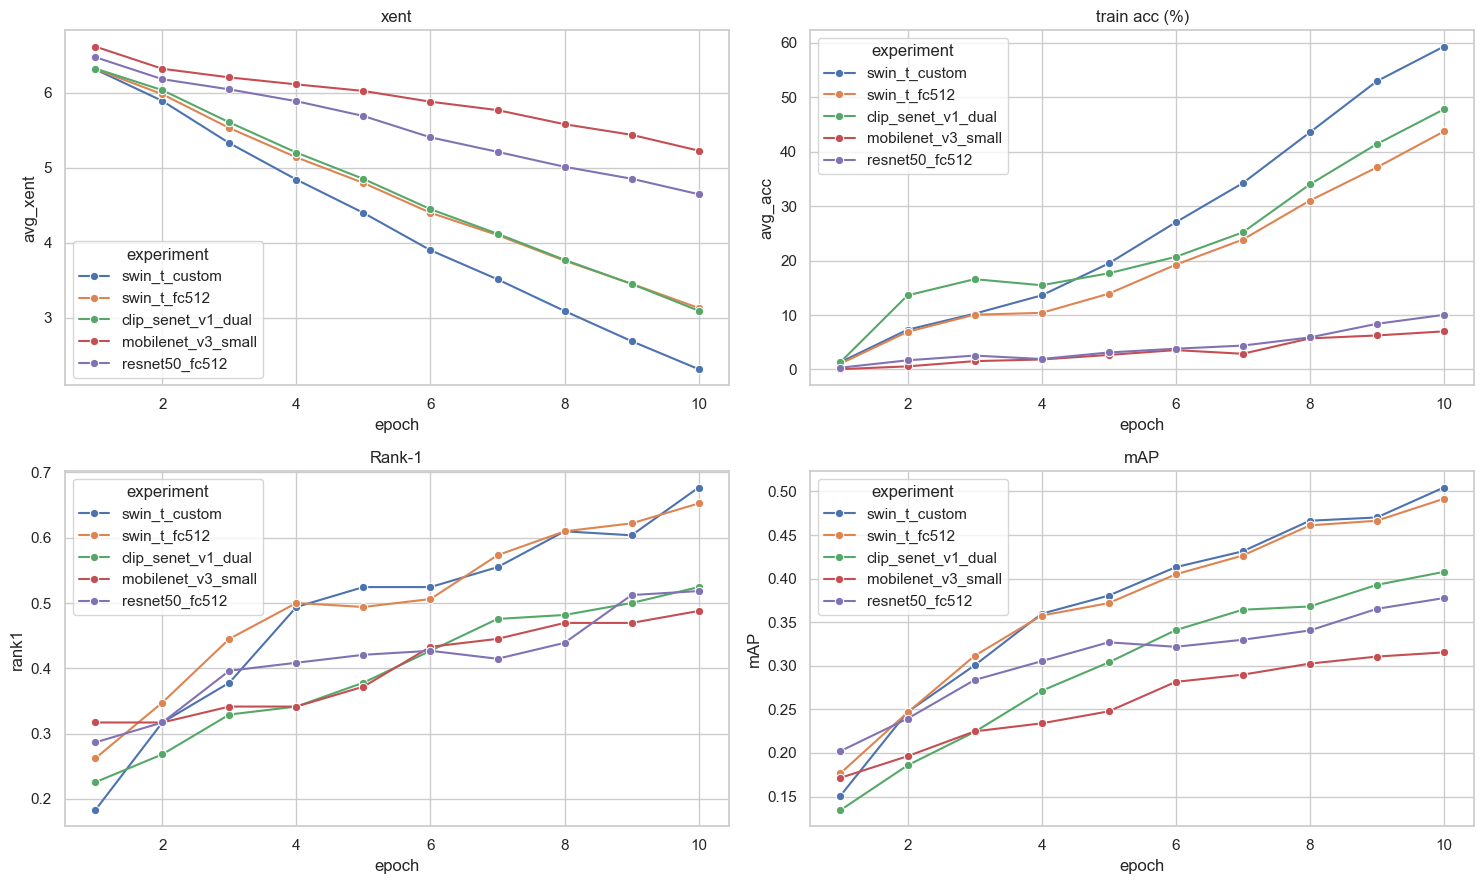

Wrote C:\Users\soura\Code\2026\reid\coursework\reports\comparison_2604_1807.html


,experiment,best_rank1,best_mAP,final_rank1,final_mAP,avg_epoch_s,total_s
0,swin_t_custom,0.676829,0.504511,0.676829,0.504511,13.377255,168.088678
1,swin_t_fc512,0.652439,0.491602,0.652439,0.491602,11.480941,140.352861
2,clip_senet_v1_dual,0.524390,0.407722,0.524390,0.407722,12.468512,171.476050
4,resnet50_fc512,0.518293,0.377662,0.518293,0.377662,12.173204,168.736910
3,mobilenet_v3_small,0.487805,0.315388,0.487805,0.315388,7.988510,128.109120


In [11]:
compare_runs(
    [f"logs/{RUNTIME}/Q1/{experiment}-veri" for experiment in SECTION_1_MODELS],
    runtime=RUNTIME,
    html=True,
)


# Section 2: Dataset preparation and augmentation experiment (25 marks)

Begin with the default data augmentation setting with random, horizontal flip and
Random2DTranslation.
1. Further append on top two additional data augmentation techniques, one at a time
e.g., Default + “crop”, Default + “horizontal flip”, and Default + “blurring”. Compare
the results with the default configuration in the provided code and discuss the
differences in performance. (20 marks)
2. Combine the augmentation techniques from Question 1 to find the best-performing
combination. Highlight any improvement or drop in the overall score. (5 marks)

## Q2 — augmentation experiments on a chosen model

Pick one model from Q1 and try each augmentation flag (`--crop-aug`, `--blur-aug`) plus their combination. Reuses `run_experiment` from above; per-experiment augmentation flags go through `extra_args`.


=== resnet50_fc512_crop  resnet50_fc512  lr=0.0003  bs=128 ===
Student ID:<your id>
Student name:<your name>
UUID:49c16737-9996-4d5a-aeb8-129334810e48
Experiment time:2026-04-26 18:53:36
Args:Namespace(root='C:\\Users\\soura\\Code\\2026\\reid\\data', source_names=['veri'], target_names=['veri'], workers=8, split_id=0, height=224, width=224, train_sampler='RandomIdentitySampler', data_fraction=0.1, random_erase=False, color_jitter=False, color_aug=False, crop_aug=False, blur_aug=True, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=10, start_epoch=0, train_batch_size=128, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='resnet50_fc512', experiment='resnet50_fc512_blur', no_pretrained=False, load_weights='', evaluate=False, eval_freq=1, start_eval=0, test_size=

### resnet50_fc512_crop  —  best Rank-1: 82.36% · best mAP: 55.41% · 694s

,epoch,epoch_time_seconds,avg_xent,avg_htri,avg_acc,rank1,rank5,rank10,rank20,mAP
0,1,107.5268,6.0310,1.6536,2.1657,0.4660,0.6818,0.7700,0.8570,0.2390
1,2,52.0614,5.1882,0.8470,5.0555,0.5602,0.7354,0.8331,0.8999,0.3245
2,3,49.9422,4.5824,0.7469,10.7733,0.6043,0.8069,0.8880,0.9237,0.3634
3,4,49.7878,4.0620,0.7321,18.4021,0.6841,0.8546,0.8975,0.9392,0.3971
4,5,49.3788,3.4900,0.6989,28.0281,0.6901,0.8474,0.9035,0.9356,0.4191
5,6,49.3674,2.9381,0.6515,37.2434,0.7366,0.8820,0.9344,0.9654,0.4609
6,7,49.3700,2.4447,0.5158,46.7601,0.7604,0.8975,0.9344,0.9583,0.4705
7,8,50.7395,1.9999,0.4335,56.1930,0.7759,0.9154,0.9476,0.9678,0.5172
8,9,51.6428,1.6712,0.3758,63.1624,0.7926,0.9046,0.9499,0.9702,0.5291
9,10,52.1820,1.3740,0.2771,70.2270,0.8236,0.9237,0.9511,0.9762,0.5541


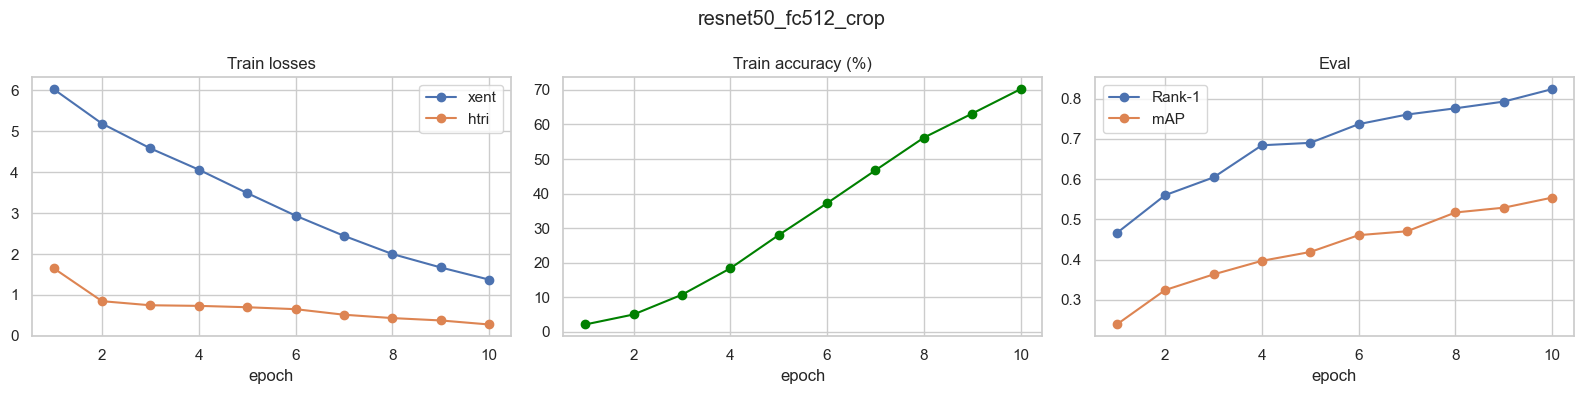


=== resnet50_fc512_blur  resnet50_fc512  lr=0.0003  bs=128 ===
Student ID:<your id>
Student name:<your name>
UUID:2280f32f-eea1-4773-97b7-cc09b0d370a4
Experiment time:2026-04-26 19:07:27
Args:Namespace(root='C:\\Users\\soura\\Code\\2026\\reid\\data', source_names=['veri'], target_names=['veri'], workers=8, split_id=0, height=224, width=224, train_sampler='RandomIdentitySampler', data_fraction=0.5, random_erase=False, color_jitter=False, color_aug=False, crop_aug=False, blur_aug=True, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=10, start_epoch=0, train_batch_size=128, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='resnet50_fc512', experiment='resnet50_fc512_blur', no_pretrained=False, load_weights='', evaluate=False, eval_freq=1, start_eval=0, test_size=

### resnet50_fc512_blur  —  best Rank-1: 81.05% · best mAP: 54.79% · 624s

,epoch,epoch_time_seconds,avg_xent,avg_htri,avg_acc,rank1,rank5,rank10,rank20,mAP
0,1,77.5721,6.1461,1.4167,2.0048,0.5054,0.7056,0.7795,0.8474,0.2776
1,2,47.7890,5.4759,0.8236,4.1044,0.5602,0.7759,0.8355,0.8999,0.3104
2,3,45.8681,4.8474,0.7520,8.9391,0.6043,0.7998,0.8665,0.9213,0.3486
3,4,45.5229,4.2112,0.7488,16.6001,0.6794,0.8570,0.9011,0.9440,0.3981
4,5,45.5766,3.5639,0.7080,26.8362,0.6806,0.8570,0.9011,0.9428,0.4177
5,6,45.6130,2.9526,0.6264,36.8727,0.7449,0.8856,0.9344,0.9595,0.4621
6,7,45.6877,2.4396,0.4987,47.1220,0.7688,0.8880,0.9261,0.9631,0.4839
7,8,45.2708,1.9762,0.3988,57.1567,0.7819,0.9082,0.9476,0.9750,0.5136
8,9,45.5668,1.6129,0.3220,64.7645,0.8057,0.9106,0.9452,0.9750,0.5421
9,10,45.5002,1.3487,0.2625,70.9455,0.8105,0.9166,0.9440,0.9678,0.5479


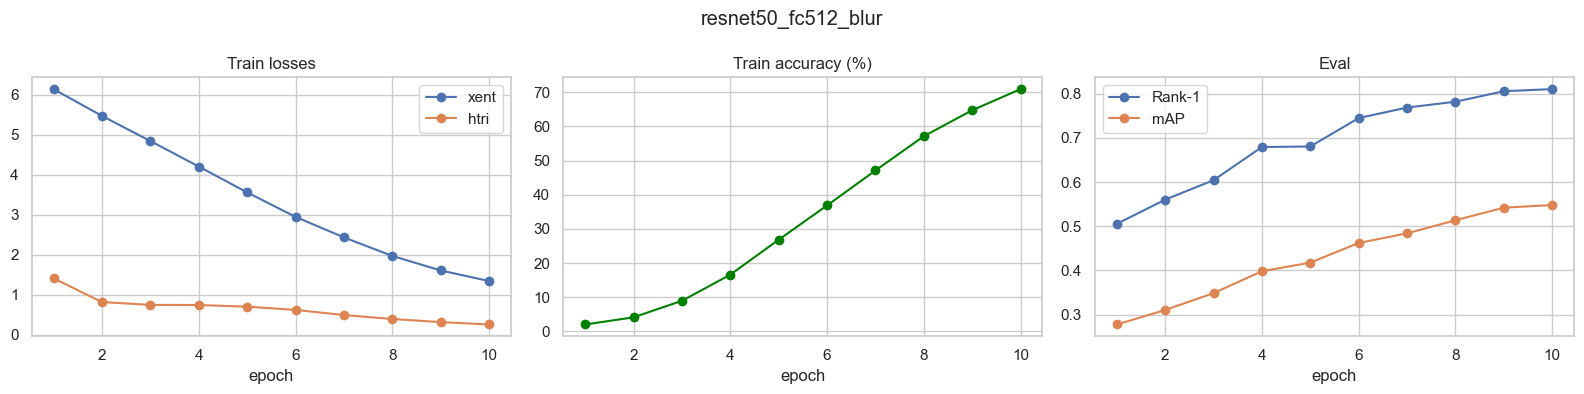


=== resnet50_fc512_combo  resnet50_fc512  lr=0.0003  bs=128 ===
Student ID:<your id>
Student name:<your name>
UUID:e0ec2ead-8599-4a12-8161-7a91e9524aa8
Experiment time:2026-04-26 19:18:01
Args:Namespace(root='C:\\Users\\soura\\Code\\2026\\reid\\data', source_names=['veri'], target_names=['veri'], workers=8, split_id=0, height=224, width=224, train_sampler='RandomIdentitySampler', data_fraction=0.5, random_erase=False, color_jitter=False, color_aug=False, crop_aug=True, blur_aug=True, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=10, start_epoch=0, train_batch_size=128, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='resnet50_fc512', experiment='resnet50_fc512_combo', no_pretrained=False, load_weights='', evaluate=False, eval_freq=1, start_eval=0, test_size

### resnet50_fc512_combo  —  best Rank-1: 82.00% · best mAP: 53.91% · 2402s

,epoch,epoch_time_seconds,avg_xent,avg_htri,avg_acc,rank1,rank5,rank10,rank20,mAP
0,1,76.5783,6.0957,1.7358,1.9014,0.4231,0.6246,0.7199,0.8212,0.2269
1,2,47.9243,5.3822,0.8155,3.9798,0.5459,0.7390,0.8164,0.8820,0.3087
2,3,46.0783,4.7652,0.7228,8.6221,0.5721,0.7664,0.8498,0.9070,0.3077
3,4,45.7062,4.2525,0.7407,15.6250,0.6150,0.8021,0.8701,0.9237,0.3594
4,5,45.7555,3.7205,0.7422,24.0762,0.6746,0.8451,0.9070,0.9452,0.4077
5,6,1820.5277,3.1335,0.6777,33.7933,0.7366,0.8903,0.9237,0.9476,0.4445
6,7,45.5484,2.6182,0.5288,43.4053,0.7640,0.8939,0.9368,0.9642,0.4821
7,8,45.4772,2.1398,0.4456,53.5869,0.7723,0.9094,0.9416,0.9642,0.5034
8,9,46.2668,1.7804,0.3571,61.1356,0.8105,0.9285,0.9559,0.9738,0.5364
9,10,46.3772,1.4700,0.2835,68.2425,0.8200,0.9237,0.9499,0.9809,0.5391


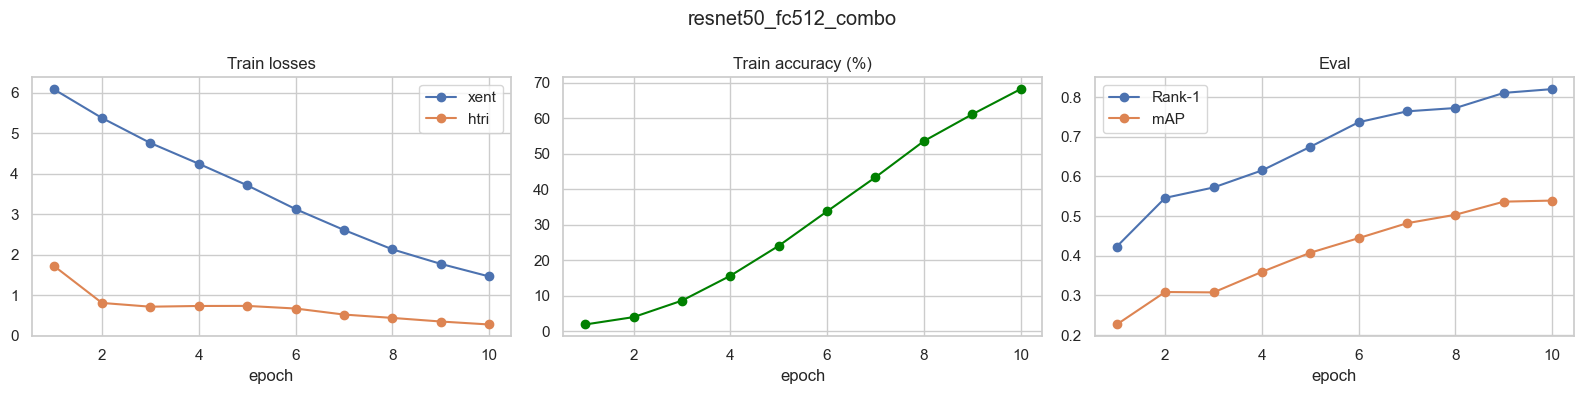

In [14]:
Q2_CHOSEN_ARCH = "resnet50_fc512"

# experiment_name -> tuple of extra CLI flags
Q2_AUGMENTATIONS = {
    f"{Q2_CHOSEN_ARCH}_crop":  ("--crop-aug",),
    f"{Q2_CHOSEN_ARCH}_blur":  ("--blur-aug",),
    f"{Q2_CHOSEN_ARCH}_combo": ("--crop-aug", "--blur-aug"),
}

for name, extras in Q2_AUGMENTATIONS.items():
    run_experiment(name, {"arch": Q2_CHOSEN_ARCH}, question="Q2", extra_args=extras)


### Compare Q2 (baseline + augmentations)

In [21]:
!ls -l logs/2604_1855

total 4
drwxr-xr-x 1 soura 197609 0 Apr 26 19:18 Q2


### Summary

,experiment,best_rank1,best_mAP,final_rank1,final_mAP,avg_epoch_s,total_s
0,resnet50_fc512_crop,82.36%,55.41%,82.36%,55.41%,56.2,694
2,resnet50_fc512_combo,82.00%,53.91%,82.00%,53.91%,226.6,2402
1,resnet50_fc512_blur,81.05%,54.79%,81.05%,54.79%,49.0,624


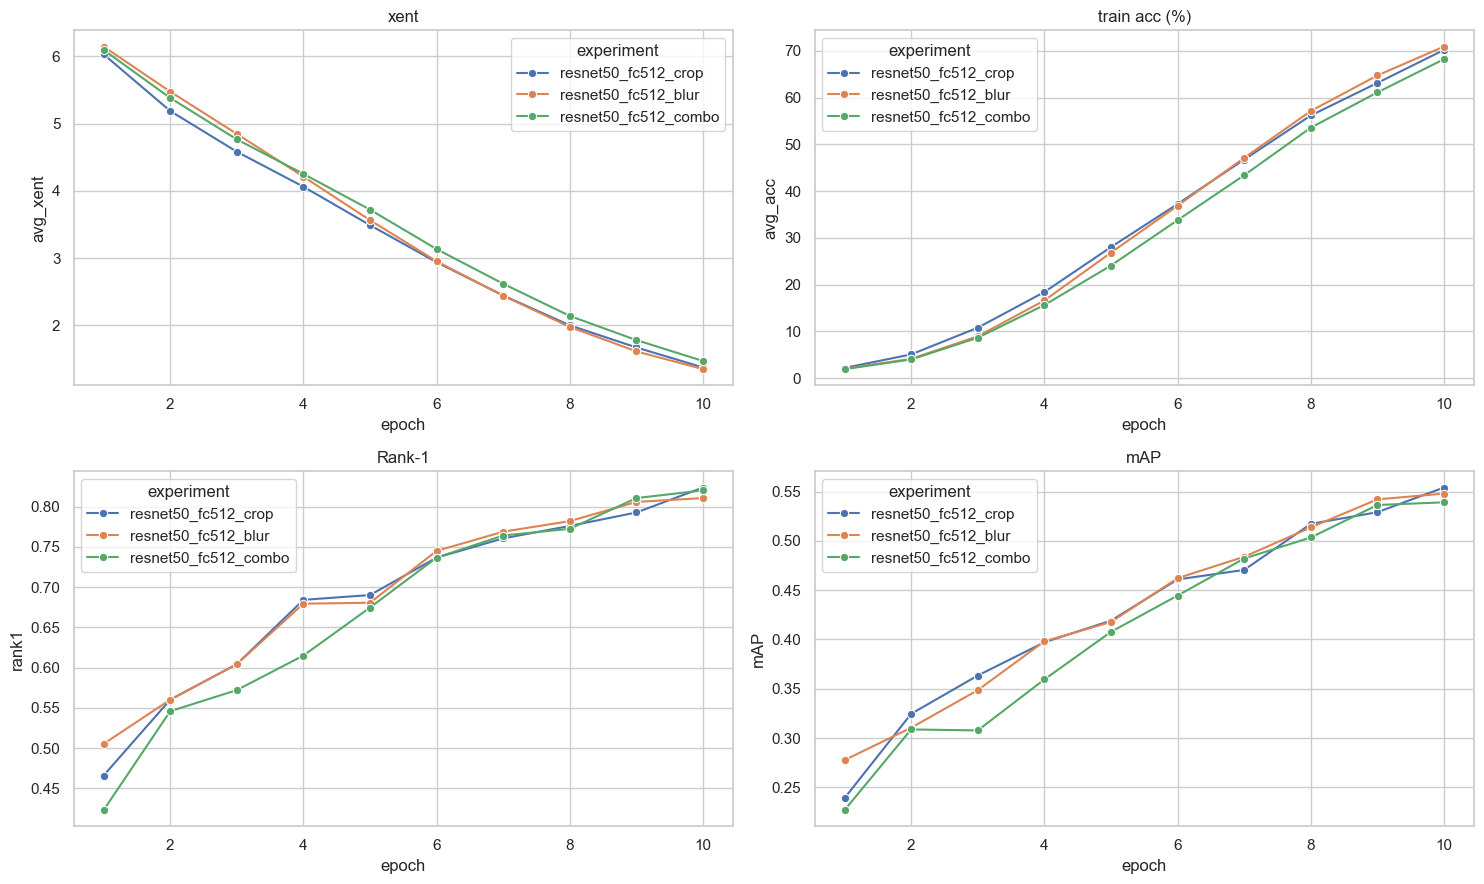

Wrote C:\Users\soura\Code\2026\reid\coursework\reports\comparison_2604_1855.html


,experiment,best_rank1,best_mAP,final_rank1,final_mAP,avg_epoch_s,total_s
0,resnet50_fc512_crop,0.823600,0.554132,0.823600,0.554132,56.199871,694.163534
2,resnet50_fc512_combo,0.820024,0.539112,0.820024,0.539112,226.623991,2402.165467
1,resnet50_fc512_blur,0.810489,0.547944,0.810489,0.547944,48.996735,624.108918


In [22]:
compare_runs(
    [f"logs/{RUNTIME}/Q1/{Q2_CHOSEN_ARCH}-veri"]
    + [f"logs/{RUNTIME}/Q2/{name}-veri" for name in Q2_AUGMENTATIONS],
    runtime=RUNTIME,
    html=True,
)


# Section 3: Exploration of Hyperparameters (25 marks)

Start with the default learning rate (LR) and batch size (BS).
1. Exploration of Learning Rate (LR). (10 marks)
a. Experiment with 4 values of LR (in addition to the default value).
b. Discuss the observed impact of each value on overall performance.
2. Exploration Batch sizes. (10 marks)
a. Fixing the best LR value from the experiments in question 1
above, test 4 different values of the BS in addition to the default
value.
b. Discuss the impact observed on overall performance.
3. Exploration of the optimizer. (5 marks)
3. Fixing the best Learning Rate value and best Batch Size value from the
experiments in Questions 1 and 2, respectively, test with changing the
optimizer to SGD, using PyTorch’s internal class.
a. Discuss the impact observed on overall performance

## Q3 — hyperparameter sweeps on a chosen model

Three sub-sweeps, run sequentially:
1. **LR sweep** at default batch size.
2. **Batch-size sweep** at the best LR from step 1 (set `BEST_LR` manually after viewing the comparison).
3. **Optimizer change** to SGD at the best LR + best BS (set `BEST_BS`).

All runs use `run_experiment` so any other knob in `BASE_CFG` can be added the same way.

In [23]:
Q3_CHOSEN_ARCH = "resnet50_fc512"

def _slug(v):
    """Filesystem-safe slug for floats and ints (e.g. 0.0003 -> "0p0003")."""
    return str(v).replace(".", "p").replace("-", "n")


### Q3.1 — Learning-rate sweep


=== resnet50_fc512_lr_0p0001  resnet50_fc512  lr=0.0001  bs=128 ===
Student ID:<your id>
Student name:<your name>
UUID:c0c24ae3-2e72-4fad-91a6-354431c4a29c
Experiment time:2026-04-26 20:15:17
Args:Namespace(root='C:\\Users\\soura\\Code\\2026\\reid\\data', source_names=['veri'], target_names=['veri'], workers=8, split_id=0, height=224, width=224, train_sampler='RandomIdentitySampler', data_fraction=0.5, random_erase=False, color_jitter=False, color_aug=False, crop_aug=False, blur_aug=False, optim='amsgrad', lr=0.0001, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=10, start_epoch=0, train_batch_size=128, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='resnet50_fc512', experiment='resnet50_fc512_lr_0p0001', no_pretrained=False, load_weights='', evaluate=False, eval_freq=1, start_eval=0,

### resnet50_fc512_lr_0p0001  —  best Rank-1: 84.98% · best mAP: 58.66% · 616s

,epoch,epoch_time_seconds,avg_xent,avg_htri,avg_acc,rank1,rank5,rank10,rank20,mAP
0,1,76.8084,6.1278,1.6196,2.5908,0.5876,0.7569,0.8248,0.9011,0.3036
1,2,45.9481,5.4364,0.7672,6.6859,0.6806,0.8403,0.8927,0.9368,0.3848
2,3,44.5756,4.8330,0.5560,14.1927,0.7223,0.8737,0.9237,0.9571,0.4323
3,4,44.9251,4.3184,0.4400,22.3711,0.7676,0.9046,0.9428,0.9666,0.4799
4,5,44.8497,3.8151,0.3401,32.3221,0.7843,0.9070,0.9535,0.9750,0.5043
5,6,44.1833,3.3209,0.2658,40.4140,0.8105,0.9297,0.9607,0.9833,0.5278
6,7,44.0892,2.8840,0.2152,48.2077,0.8153,0.9273,0.9619,0.9785,0.5521
7,8,45.0407,2.4544,0.1672,56.3926,0.8176,0.9356,0.9631,0.9809,0.5607
8,9,45.2805,2.0810,0.1316,64.0285,0.8355,0.9356,0.9607,0.9797,0.5772
9,10,44.7632,1.7664,0.1052,69.9703,0.8498,0.9356,0.9690,0.9809,0.5866


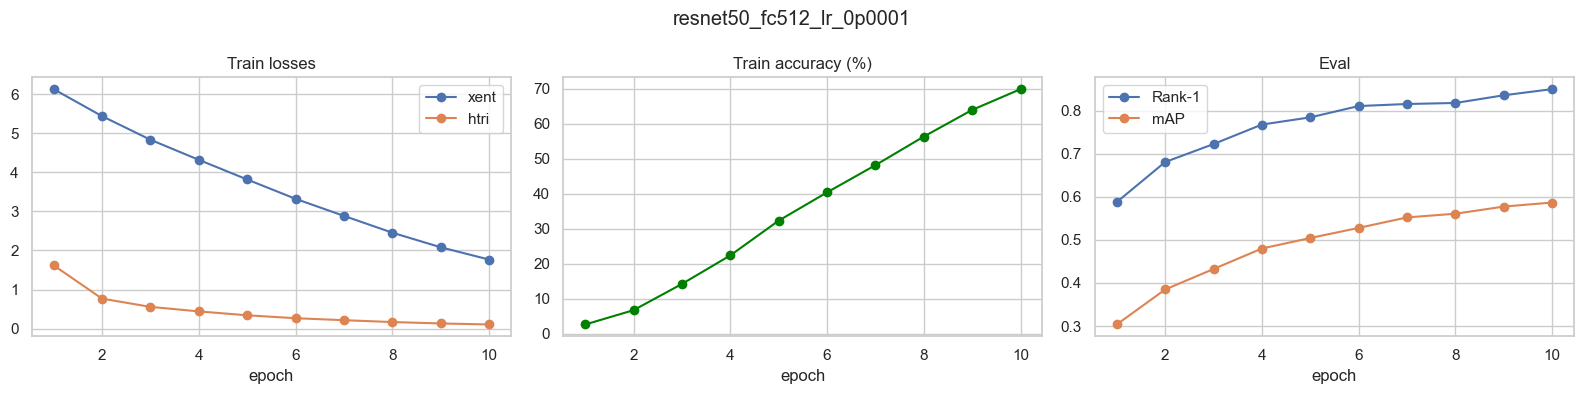


=== resnet50_fc512_lr_0p0003  resnet50_fc512  lr=0.0003  bs=128 ===
^C


FileNotFoundError: No runs found under logs\2604_1855\Q3\resnet50_fc512_lr_0p0003-veri_*

In [24]:
Q3_LR_VALUES = ["0.0001", "0.0003", "0.001", "0.005", "0.01"]

Q3_LR_SWEEP = {
    f"{Q3_CHOSEN_ARCH}_lr_{_slug(lr)}": {"arch": Q3_CHOSEN_ARCH, "lr": lr}
    for lr in Q3_LR_VALUES
}

for name, cfg in Q3_LR_SWEEP.items():
    run_experiment(name, cfg, question="Q3")


In [ ]:
compare_runs(
    [f"logs/{RUNTIME}/Q3/{name}-veri" for name in Q3_LR_SWEEP],
    runtime=RUNTIME,
    html=True,
)


### Q3.2 — Batch-size sweep at best LR

Set `BEST_LR` to the winner from Q3.1 before running.

In [ ]:
BEST_LR = "0.0003"  # <-- update after Q3.1

Q3_BS_VALUES = [16, 32, 64, 128, 256]

Q3_BS_SWEEP = {
    f"{Q3_CHOSEN_ARCH}_lr{_slug(BEST_LR)}_bs{bs}": {
        "arch": Q3_CHOSEN_ARCH, "lr": BEST_LR, "train_batch_size": bs
    }
    for bs in Q3_BS_VALUES
}

for name, cfg in Q3_BS_SWEEP.items():
    run_experiment(name, cfg, question="Q3")


In [ ]:
compare_runs(
    [f"logs/{RUNTIME}/Q3/{name}-veri" for name in Q3_BS_SWEEP],
    runtime=RUNTIME,
    html=True,
)


### Q3.3 — SGD at best LR + best BS

Set `BEST_BS` to the winner from Q3.2.

In [ ]:
BEST_BS = 128  # <-- update after Q3.2

Q3_OPTIM_SWEEP = {
    f"{Q3_CHOSEN_ARCH}_sgd_lr{_slug(BEST_LR)}_bs{BEST_BS}": {
        "arch": Q3_CHOSEN_ARCH,
        "lr": BEST_LR,
        "train_batch_size": BEST_BS,
        "optim": "sgd",
    },
}

for name, cfg in Q3_OPTIM_SWEEP.items():
    run_experiment(name, cfg, question="Q3")


In [ ]:
compare_runs(
    [
        f"logs/{RUNTIME}/Q1/{Q3_CHOSEN_ARCH}-veri",  # original AMSGrad baseline
        *[f"logs/{RUNTIME}/Q3/{name}-veri" for name in Q3_OPTIM_SWEEP],
    ],
    runtime=RUNTIME,
    html=True,
)


In [ ]:
NOTEBOOK_END_TIME = datetime.now()
NOTEBOOK_RUNTIME = (NOTEBOOK_END_TIME - NOTEBOOK_START_TIME).total_seconds()
print(f"Notebook Run time: {NOTEBOOK_RUNTIME:.2f} seconds")